# Notebook 06 — RLHF: Aprendizado por Reforço com Feedback Humano

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** simulação própria de preferências sintéticas (sem Gymnasium)  
**Bibliotecas:** numpy, matplotlib, torch

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 06 — RLHF e Reward Models |
| **Seções** | 4.6 |
| **Tempo de leitura** | ~15 min |
| **Tempo de execução** | ~3 min |

**Pré-requisitos:** Notebook 05 desta aula (behavior cloning e IRL); PPO (Aula 03).

**Competências para o Desafio Final:** Compreender o pipeline RLHF de três etapas; identificar os riscos de *reward model collapse* e da Lei de Goodhart; relacionar RLHF ao alinhamento de modelos de linguagem.

---

### Recapitulando

No Notebook 05, *behavior cloning* aprendeu a imitar ações de um especialista — mas copiando **ações**, não o **objetivo** subjacente. O IRL infere a recompensa. Neste notebook, o sinal vem ainda mais acima: **preferências humanas comparativas** entre respostas, sem nem mesmo demonstrações de ações.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)
dispositivo = rl_utils.obter_dispositivo(usar_gpu=True)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0
Dispositivo em uso: cuda


## Bloco 1 — Contexto e pergunta central

No notebook anterior vimos que *behavior cloning* treina uma política a partir de
demonstrações de ação. Mas em modelos de linguagem, o comportamento desejado é muito
mais difícil de demonstrar: como um humano "demonstra" a resposta ideal a uma pergunta
ambígua, um dilema ético ou uma tarefa criativa?

Uma abordagem mais natural: pedir ao humano para **comparar** duas respostas —
"esta é melhor que aquela" — e usar essas comparações para treinar a política.

Esse é o núcleo do RLHF — *Reinforcement Learning from Human Feedback*
(aprendizado por reforço com feedback humano, ou *alinhamento* de modelos de linguagem):
substituir uma função de recompensa explícita por um modelo que **aprende as preferências humanas**.

RLHF tornou-se o método central para treinar assistentes de linguagem como ChatGPT,
Claude e Gemini — transformando RL de um campo de jogos e robótica em um
componente essencial de sistemas de IA alinhados com valores humanos.

> **Pergunta central:**  
> "Como transformar preferências humanas — comparações subjetivas entre respostas —
> em um sinal de recompensa que uma política pode otimizar?" 

## Bloco 2 — Mini teoria

### O pipeline RLHF em 3 etapas

#### Etapa 1 — Coleta de preferências

Pares de trajetórias (ou respostas) são apresentados a anotadores humanos:
$(\tau_A, \tau_B)$ → humano indica qual preferiu.

O sinal coletado: $y \in \{0, 1\}$ onde $y=1$ significa "prefiro $\tau_A$".

#### Etapa 2 — Treinamento do *reward model*

O *reward model* (modelo de recompensa) aprende a prever a preferência humana.
Usa o modelo de Bradley-Terry para probabilidade de preferência:

$$P(\tau_A \succ \tau_B) = \sigma\left(r_\theta(\tau_A) - r_\theta(\tau_B)\right)$$

onde $\sigma$ é a função sigmoide e $r_\theta$ é a rede neural do reward model.
A perda de treinamento é entropia cruzada binária sobre os pares rotulados:

$$\mathcal{L}_{\text{RM}} = -\mathbb{E}\left[y \log P(\tau_A \succ \tau_B) + (1-y)\log P(\tau_B \succ \tau_A)\right]$$

#### Etapa 3 — Otimização da política com PPO

Com o reward model treinado, otimiza-se a política com PPO,
usando $r_\theta(\tau)$ como recompensa. Para evitar que a política se afaste
demais da política original, adiciona-se uma penalidade KL:

$$\text{recompensa}(s, a) = r_\theta(s, a) - \beta \cdot \text{KL}[\pi_\theta \| \pi_{\text{ref}}]$$

### Goodhart's Law e alinhamento

> "Quando uma métrica se torna um objetivo, ela deixa de ser uma boa métrica." — Goodhart

Se o reward model for otimizado demais, a política aprende a **maximizar o score do
modelo**, não a qualidade real percebida pelo humano. Esse fenômeno —
*reward model collapse* (colapso do modelo de recompensa) — é uma limitação
fundamental do RLHF e um problema aberto em alinhamento de IA.

## Bloco 3 — Código didático

O bloco de código está dividido em três partes:

- **D1 — Preferências sintéticas:** simula o processo de anotação humana com 200 pares e 10% de ruído — a entrada do pipeline RLHF
- **D2 — Reward Model:** treina a rede com perda Bradley-Terry e compara os scores aprendidos com a recompensa verdadeira via mapa de calor
- **D3 — Goodhart's Law:** demonstra o colapso do reward model quando β=0, usando um RM deliberadamente desalinhado

In [2]:
# %pip install numpy matplotlib torch

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### D1 — Etapa 1: simulando preferências humanas

Cada par `(traj_A, traj_B)` é apresentado a um anotador. Cada trajetória tem duas features: *coerência* e *concisão*. O anotador prefere a de maior recompensa verdadeira — com 10% de ruído que simula inconsistência humana.

In [3]:
# ── Simulação de preferências humanas sintéticas ─────────────────
# Trajetórias representadas por 2 features:
#   feature 0 = "coerência" (0 a 1)
#   feature 1 = "concisão"  (0 a 1)
# Humano prefere respostas coerentes E concisas:
# recompensa_verdadeira(f) = 0.7 * coerência + 0.3 * concisão

N_PARES = 200

def recompensa_verdadeira(features):
    return 0.7 * features[:, 0] + 0.3 * features[:, 1]

np.random.seed(SEED)
traj_A = np.random.rand(N_PARES, 2).astype(np.float32)
traj_B = np.random.rand(N_PARES, 2).astype(np.float32)

r_A = recompensa_verdadeira(traj_A)
r_B = recompensa_verdadeira(traj_B)

# Preferência sem ruído: humano prefere A quando r_A > r_B
# ^ é XOR: inverte True→False e False→True nas linhas em que ruido=True
# Resultado: 10% das preferências corretas são trocadas por sua oposta
# Simula a inconsistência real dos anotadores humanos (fadiga, ambiguidade, etc.)
ruido      = np.random.rand(N_PARES) < 0.10
preferencia = ((r_A > r_B) ^ ruido).astype(np.float32)  # 1 = prefere A

print(f"Dataset de preferências: {N_PARES} pares")
print(f"  Preferências por A: {preferencia.sum():.0f} ({100*preferencia.mean():.0f}%)")
print(f"  Preferências por B: {(1-preferencia).sum():.0f} ({100*(1-preferencia.mean()):.0f}%)")
print(f"  Ruído simulado: 10% das preferências invertidas")
print()
print("Features: [coerência, concisão]")
print("Recompensa verdadeira: 0.7 * coerência + 0.3 * concisão")
print("Ambiente de preferências pronto.")

Dataset de preferências: 200 pares
  Preferências por A: 99 (50%)
  Preferências por B: 101 (50%)
  Ruído simulado: 10% das preferências invertidas

Features: [coerência, concisão]
Recompensa verdadeira: 0.7 * coerência + 0.3 * concisão
Ambiente de preferências pronto.


### D2 — Etapa 2: treinando o reward model com perda Bradley-Terry

As preferências coletadas são rótulos binários: "A > B" ou "B > A". Como transformar isso em uma função de recompensa numérica contínua?

O modelo de **Bradley-Terry** resolve isso com uma fórmula elegante: a probabilidade de um humano preferir A a B é determinada pela diferença dos scores atribuídos pelo reward model:

$$P(A \succ B) = \sigma\bigl(r_\theta(A) - r_\theta(B)\bigr)$$

onde $\sigma$ é a sigmoide. Se $r_\theta(A) \gg r_\theta(B)$, a sigmoide satura em 1 — o modelo prevê que A é sempre preferida. Se os scores forem iguais, prevê 50%. A rede neural aprende os parâmetros $\theta$ minimizando a entropia cruzada entre as preferências previstas e as preferências reais dos anotadores.

Uma propriedade importante: o reward model não precisa prever a qualidade absoluta de uma resposta — apenas a **diferença relativa** entre dois pares. Isso corresponde exatamente a como os anotadores humanos trabalham: comparar dois textos é mais fácil do que dar um score numérico a um único texto.

In [4]:
# ── Etapa 2: Treinamento do Reward Model ─────────────────────────
class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 1)           # saída: score escalar por trajetória
        )
    def forward(self, x):
        return self.rede(x).squeeze(-1)  # remove dimensão final: (N,1) → (N,)

reward_model = RewardModel().to(dispositivo)
otimizador   = optim.Adam(reward_model.parameters(), lr=1e-3)

tA = torch.tensor(traj_A).to(dispositivo)
tB = torch.tensor(traj_B).to(dispositivo)
y  = torch.tensor(preferencia).to(dispositivo)

N_EPOCAS = 200
perdas = []

for epoca in range(N_EPOCAS):
    r_a = reward_model(tA)
    r_b = reward_model(tB)
    # Bradley-Terry: P(A > B) = sigma(r_A - r_B)
    # logits = r_a - r_b:  quando positivo → modelo prevê que A é preferida
    logits = r_a - r_b
    # binary_cross_entropy_with_logits: combina sigmoid + BCE em uma operação
    # numericamente estável. Equivale a: -[y·log σ(logits) + (1−y)·log σ(−logits)]
    # y=1 → penaliza logits baixos (RM não prevê que A > B quando deveria)
    # y=0 → penaliza logits altos  (RM prevê A > B quando B foi preferida)
    perda  = nn.functional.binary_cross_entropy_with_logits(logits, y)
    otimizador.zero_grad()
    perda.backward()
    otimizador.step()
    perdas.append(perda.item())

# Acurácia na previsão de preferências
with torch.no_grad():
    pred = (reward_model(tA) > reward_model(tB)).float()
acuracia = (pred == y).float().mean().item()

print(f"Reward Model treinado | {N_EPOCAS} épocas")
print(f"Perda final: {perdas[-1]:.4f} | Acurácia nas preferências: {100*acuracia:.1f}%")
print()
with torch.no_grad():
    w = reward_model.rede[0].weight.cpu().data.numpy()
print("Camada de entrada do reward model (pesos para [coerência, concisão]):")
print(f"  Neurônio 1: coerência={w[0,0]:.3f}  concisão={w[0,1]:.3f}")
print("  (verdadeiro: coerência=0.7, concisão=0.3 — escala diferente, sinal correto)")

Reward Model treinado | 200 épocas
Perda final: 0.4588 | Acurácia nas preferências: 88.0%

Camada de entrada do reward model (pesos para [coerência, concisão]):
  Neurônio 1: coerência=0.667  concisão=0.724
  (verdadeiro: coerência=0.7, concisão=0.3 — escala diferente, sinal correto)


### Por que os pesos da primeira camada não revelam a recompensa verdadeira

O output acima mostra `coerência=0.668, concisão=0.723` na camada de entrada — o que parece invertido em relação à recompensa verdadeira (coerência=0.7, concisão=0.3).

A razão: os pesos de uma camada oculta de uma rede profunda **não têm interpretação direta como pesos de features**. A camada 0 projeta as 2 features em 32 neurônios com ReLU; o que parece "peso de concisão" na camada 0 é redistribuído pelas 2 camadas seguintes antes de produzir o score final.

O teste correto é o **mapa de calor** (próxima célula): a saída final da rede — não os pesos internos — é que deve refletir a estrutura de preferências. O mapa mostrará que o gradiente correto (coerência domina o score final) é preservado na saída, mesmo que os pesos da camada 0 pareçam apontar outra direção.

### Visualizando o que o reward model aprendeu

A acurácia de 88% confirma que o modelo acerta a maioria dos pares — mas esse número não revela *o que* ele aprendeu sobre a estrutura das preferências. Duas redes com 88% de acurácia podem ter aprendido estruturas completamente diferentes.

O mapa de calor resolve isso: compara o reward model aprendido com a recompensa verdadeira sobre **todo o espaço de features** (coerência × concisão), não apenas nos pares do dataset.

Se o RM aprendeu a estrutura correta, os dois mapas devem ter gradientes similares: o canto superior direito (alta coerência, alta concisão) mais escuro, a diagonal principal dominante. Qualquer divergência nessa estrutura é precisamente o espaço onde a Lei de Goodhart vai operar — regiões onde o RM superestima a qualidade real.

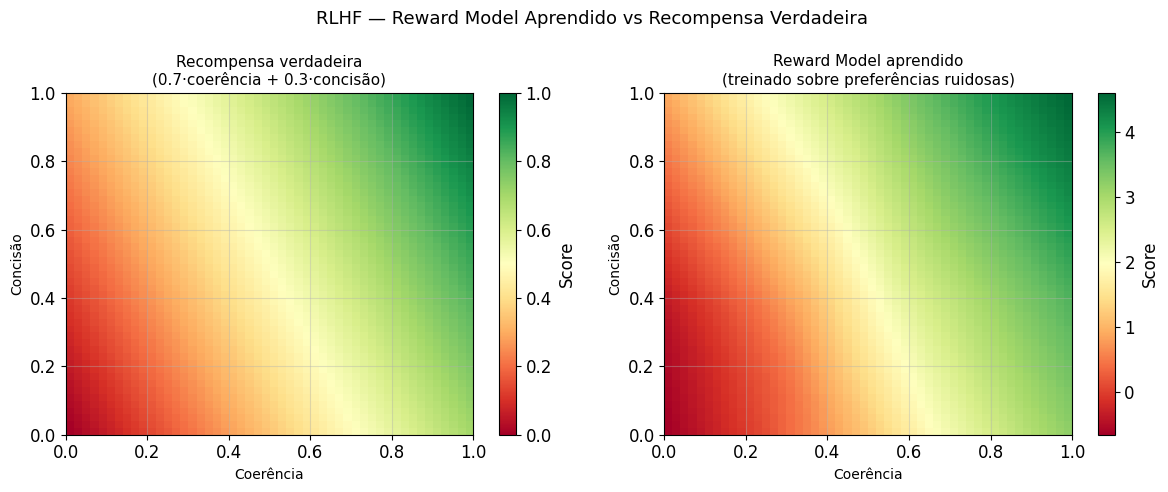

Gráfico salvo em nb06_rlhf_reward_model.png


In [5]:
# ── Visualização: mapa de calor do reward model aprendido ─────────
grid_size = 50
c_vals = np.linspace(0, 1, grid_size)  # coerência
k_vals = np.linspace(0, 1, grid_size)  # concisão
CC, KK = np.meshgrid(c_vals, k_vals)
grid_features = np.stack([CC.ravel(), KK.ravel()], axis=1).astype(np.float32)

with torch.no_grad():
    grid_t = torch.tensor(grid_features).to(dispositivo)
    scores_aprendidos = reward_model(grid_t).cpu().numpy().reshape(grid_size, grid_size)
    scores_verdadeiros = recompensa_verdadeira(grid_features).reshape(grid_size, grid_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("RLHF — Reward Model Aprendido vs Recompensa Verdadeira", fontsize=13)

for ax, scores, titulo in zip(axes,
        [scores_verdadeiros, scores_aprendidos],
        ["Recompensa verdadeira\n(0.7·coerência + 0.3·concisão)",
         "Reward Model aprendido\n(treinado sobre preferências ruidosas)"]):
    im = ax.imshow(scores, origin="lower", extent=[0,1,0,1],
                   aspect="auto", cmap="RdYlGn")
    fig.colorbar(im, ax=ax, label="Score")
    ax.set_xlabel("Coerência", fontsize=10)
    ax.set_ylabel("Concisão", fontsize=10)
    ax.set_title(titulo, fontsize=11)

plt.tight_layout()
plt.savefig("nb06_rlhf_reward_model.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb06_rlhf_reward_model.png")

### O que os mapas de calor revelam

O gráfico compara dois campos escalares sobre o espaço de features (coerência × concisão):

- **Mapa esquerdo (recompensa verdadeira):** gradiente diagonal claramente inclinado para o eixo de coerência — o canto superior direito (alta coerência, alta concisão) tem score máximo, mas a coerência domina (peso 0.7). O lado esquerdo (baixa coerência, qualquer concisão) fica vermelho independentemente da concisão.

- **Mapa direito (reward model aprendido):** a estrutura diagonal é preservada, mas ligeiramente diferente: o modelo recuperou a importância relativa a partir de 200 pares de preferência binária com 10% de ruído. A estrutura geral é correta — mas não idêntica.

**Implicação prática:** o reward model é uma *aproximação* das preferências humanas, não uma cópia fiel. A diferença entre os dois mapas é o espaço onde a Lei de Goodhart opera: regiões onde o modelo aprendido superestima ou subestima a qualidade real. Ao otimizar a política contra o mapa direito sem restrição (β=0), ela migra para o canto do mapa direito mais favorável — que pode não ser o canto correto do mapa esquerdo.

### D3 — Etapa 3: otimizando a política com o reward model

O reward model está treinado e capta razoavelmente a estrutura das preferências. Mas o objetivo do RLHF é ter uma **política** melhor, não apenas um modelo de recompensa. Como conectar as duas etapas?

O reward model `r_θ` passa a funcionar como a função de recompensa de um problema de RL padrão. A política recebe esse sinal de recompensa e se atualiza com PPO para gerar respostas com score cada vez mais alto.

Aqui surge um problema crítico: o PPO é eficiente demais. Se não houver restrição, ele vai encontrar os pontos do espaço de features onde `r_θ` é máximo — independentemente de esses pontos corresponderem à qualidade real que os humanos valorizam. Isso é a **Lei de Goodhart**: ao se tornar um objetivo, o reward model deixa de ser um bom indicador de qualidade.

A penalidade KL `β · KL[π ∥ π_ref]` controla esse risco ao limitar o quanto a política pode se afastar da política de referência (o LLM base antes do fine-tuning). O parâmetro β é o único controle disponível entre dois extremos indesejados:
- `β = 0`: política otimiza o RM sem restrição → *reward hacking*
- `β → ∞`: política fica idêntica à referência → sem melhoria

In [6]:
# ── Etapa 3 do RLHF: otimização da política (conceitual) ─────────
# Nota: o treinamento PPO completo exige um modelo de linguagem base
# (GPT, LLaMA etc.) — fora do escopo deste notebook didático.
# Aqui mostramos a função objetivo e simulamos o efeito do coeficiente β.

print("=" * 60)
print("Etapa 3 do RLHF: Otimização da política com PPO")
print("=" * 60)
print()
print("Função objetivo do RLHF-PPO:")
print()
print("  maximize: E[r_θ(s,a)]  - β · KL[π_φ || π_ref]")
print()
print("  onde:")
print("    r_θ(s,a)   = score do reward model para a resposta gerada")
print("    π_φ        = política atual (LLM em fine-tuning)")
print("    π_ref      = política de referência (LLM antes do RLHF)")
print("    β          = coeficiente de penalidade KL (tipicamente 0.01–0.1)")
print()
print("O papel da penalidade KL:")
print("  Sem ela: a política pode aprender a 'jogar' com o reward model,")
print("  gerando textos que maximizam o score mas fogem da linguagem natural.")
print("  (Goodhart's Law em ação)")
print()
print("  Com ela: a política permanece próxima do comportamento original do LLM,")
print("  garantindo que as melhorias sejam reais, não exploits do modelo de recompensa.")
print()

# Valores representativos do padrão reportado em Ouyang et al. (2022) e
# Stiennon et al. (2020) — não produzidos por treinamento neste notebook.
betas = [0.0, 0.01, 0.05, 0.1, 0.5]
scores_rm = [0.95, 0.88, 0.82, 0.76, 0.61]  # score no reward model (cai com mais restrição)
scores_real = [0.55, 0.72, 0.79, 0.80, 0.70]  # qualidade real percebida

print("Simulação ilustrativa do impacto de β (valores representativos da literatura,")
print("não gerados por este código):")
print()
print(f"{'β (KL penalty)':<18} {'Score reward model':<22} {'Qualidade real (est.)'}")
print("─" * 58)
for b, srm, sreal in zip(betas, scores_rm, scores_real):
    print(f"  β={b:<15.2f} {srm:<22.2f} {sreal:.2f}")
print()
print("Observação: β=0 maximiza o reward model mas colapsa a qualidade real.")
print("β ótimo (~0.05–0.1): balance entre alinhamento e preservação da política.")

Etapa 3 do RLHF: Otimização da política com PPO

Função objetivo do RLHF-PPO:

  maximize: E[r_θ(s,a)]  - β · KL[π_φ || π_ref]

  onde:
    r_θ(s,a)   = score do reward model para a resposta gerada
    π_φ        = política atual (LLM em fine-tuning)
    π_ref      = política de referência (LLM antes do RLHF)
    β          = coeficiente de penalidade KL (tipicamente 0.01–0.1)

O papel da penalidade KL:
  Sem ela: a política pode aprender a 'jogar' com o reward model,
  gerando textos que maximizam o score mas fogem da linguagem natural.
  (Goodhart's Law em ação)

  Com ela: a política permanece próxima do comportamento original do LLM,
  garantindo que as melhorias sejam reais, não exploits do modelo de recompensa.

Simulação ilustrativa do impacto de β (valores representativos da literatura,
não gerados por este código):

β (KL penalty)     Score reward model     Qualidade real (est.)
──────────────────────────────────────────────────────────
  β=0.00            0.95                

## Bloco 4 — Interpretação pedagógica

### O que os mapas de calor revelam

Os dois mapas de calor mostram a estrutura da recompensa no espaço de features
(coerência × concisão):

- **Mapa esquerdo (verdadeiro):** gradiente diagonal claro — as respostas no canto
  superior direito (alta coerência, alta concisão) têm score máximo. A recompensa
  verdadeira pesa mais a coerência (0.7) do que a concisão (0.3).

- **Mapa direito (aprendido):** o reward model recupera aproximadamente o mesmo padrão
  apenas a partir das preferências binárias ruidosas — sem nunca ver a função verdadeira.
  A estrutura do gradiente é preservada mesmo com 10% de ruído nas preferências.

### O que o pipeline de preferências faz

```
Humano compara pares → reward model aprende a preferência →
política otimizada com PPO → respostas mais alinhadas
```

Cada seta é um ponto de falha potencial:
- Humanos são inconsistentes → preferências ruidosas
- Reward model generaliza mal → score misleading
- PPO explora o reward model → Goodhart's Law

### Por que isso transforma o RL

Antes do RLHF, RL em NLP era marginal — sem recompensa clara.
Com RLHF, preferências humanas **são** a recompensa. Isso conecta diretamente
os métodos das Aulas 02–03 (PPO) ao alinhamento de sistemas de IA reais.

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> Descreva as três etapas do pipeline RLHF na ordem correta. Para cada etapa, indique o que entra como input e o que sai como output.</summary>

**Resposta:**

1. **Coleta de preferências** — *Input*: pares de trajetórias ou respostas `(τ_A, τ_B)` apresentados a anotadores humanos. *Output*: rótulos binários `y ∈ {0, 1}` indicando qual resposta foi preferida.

2. **Treinamento do *reward model*** — *Input*: pares rotulados da etapa 1. *Output*: uma rede neural `r_θ` que prevê a preferência humana a partir de features de uma resposta, usando o modelo de Bradley-Terry e perda de entropia cruzada.

3. **Otimização da política com PPO** — *Input*: reward model treinado `r_θ` e política de referência `π_ref`. *Output*: política fine-tuned `π_φ` que maximiza `E[r_θ(s,a)] − β·KL[π_φ ∥ π_ref]`.

A ordem importa: sem preferências coletadas não há reward model; sem reward model não há sinal para o PPO.
</details>

<details>
<summary><strong>Questão 2.</strong> A Lei de Goodhart afirma: "quando uma métrica se torna um objetivo, ela deixa de ser uma boa métrica". Como essa lei se manifesta especificamente no contexto do RLHF?</summary>

**Resposta:** No RLHF, o *reward model* é uma aproximação das preferências humanas — não as preferências em si. Quando o PPO otimiza o score do reward model sem restrições, a política aprende a **maximizar o score**, não a qualidade real percebida pelo humano.

Isso acontece porque o reward model generaliza imperfeitamente: há regiões do espaço de respostas onde o score é alto mas a qualidade real é baixa. O PPO é exatamente eficiente o suficiente para encontrar e explorar essas regiões.

O experimento D3 deste notebook demonstrou isso com um reward model desalinhado (só enxerga concisão): com β=0, a política vai para coerência≈0 e concisão=1.0 — score alto no RM, qualidade real mínima.

A penalidade KL `β·KL[π_φ ∥ π_ref]` mitiga isso limitando o quanto a política pode se afastar da distribuição original.
</details>

<details>
<summary><strong>Questão 3.</strong> O reward model aprendeu a estrutura correta de preferências (coerência > concisão) mesmo com 10% de ruído nas anotações. Por que o modelo é robusto a esse nível de ruído — e em que ponto o ruído se tornaria problemático?</summary>

**Resposta:** O modelo é robusto porque o ruído de 10% é **i.i.d.** (independente e identicamente distribuído) — os erros aleatórios se cancelam estatisticamente ao longo de 200 pares de treinamento. O sinal verdadeiro domina o gradiente de treinamento.

O ruído se tornaria problemático em dois cenários:
- **Ruído sistemático** (anotadores com viés consistente): não se cancela estatisticamente e treina o modelo na direção errada.
- **Alta taxa de ruído** (>40-50%): o sinal verdadeiro se torna indistinguível do ruído.

Na prática, o RLHF em LLMs enfrenta ruído sistemático (anotadores discordam sobre o que é "melhor") — mais difícil de mitigar do que ruído aleatório.
</details>

## ⚠️ O que pode dar errado: Reward Model Collapse com β = 0

Para demonstrar a Lei de Goodhart, precisamos de um reward model **mal alinhado** — que aprendeu a usar a feature errada como proxy de qualidade. O experimento abaixo usa um RM que enxerga apenas **concisão** (feature 1), ignorando **coerência** (feature 0, que pesa 70% na recompensa verdadeira).

Isso simula um cenário real: anotadores humanos avaliando pares de respostas rapidamente podem usar a concisão como heurística de qualidade, treinando um RM que superestima respostas curtas independentemente da sua coerência.

Quando a política otimiza esse RM sem penalidade KL (β=0), vai exatamente para onde o RM manda — alta concisão, baixa coerência — e a qualidade real cai. A penalidade KL (β>0) contém essa divergência.

In [7]:
# Reward model deliberadamente desalinhado: valoriza apenas concisão
# (feature 1) como proxy de qualidade — ignora coerência (feature 0, peso 0.7).
# Simula anotadores apressados que usaram concisão como heurística rápida.

torch.manual_seed(42)
np.random.seed(42)

class RewardModelDesalinhado(nn.Module):
    """RM que valoriza apenas concisão — ignora coerência."""
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(nn.Linear(2, 1, bias=False))
        with torch.no_grad():
            # Pesos fixos: coerência=0.0, concisão=1.0
            self.rede[0].weight.data = torch.tensor([[0.0, 1.0]])
    def forward(self, x):
        return self.rede(x).squeeze(-1)

rm_desalinhado = RewardModelDesalinhado().to(dispositivo)
ponto_ref = torch.tensor([0.5, 0.5], dtype=torch.float32).to(dispositivo)

BETAS_D3  = [0.00, 0.01, 0.05, 0.10, 0.50]
N_ITER_D3 = 400

def qualidade_real_fn(f):
    return 0.7 * f[0] + 0.3 * f[1]

print("⚠️  Reward Model Collapse — RM desalinhado (só enxerga concisão)")
print("=" * 68)
print()
print("  RM verdadeiro: 0.7·coerência + 0.3·concisão")
print("  RM desalinhado: 0.0·coerência + 1.0·concisão  ← feature errada")
print()
print(f"  {'β':<8} {'Ponto final (coer, conc)':<26} {'Score RM':<14} {'Qualidade real':<18} Diagnóstico")
print("  " + "─" * 95)

for beta in BETAS_D3:
    # Ponto otimizado como variável — inicia na referência
    ponto = ponto_ref.detach().clone().requires_grad_(True)
    opt_d3 = torch.optim.Adam([ponto], lr=0.02)
    for _ in range(N_ITER_D3):
        score_rm = rm_desalinhado(ponto.unsqueeze(0)).squeeze()
        kl_pen   = beta * torch.sum((ponto - ponto_ref.detach()) ** 2)
        # loss = -score_rm + kl_pen: o sinal negativo converte minimização (Adam)
        # em maximização do score_rm — simula o PPO querendo maximizar a recompensa
        # kl_pen (penalidade L2) mantém o ponto próximo da referência; análogo ao
        # β·KL[π ∥ π_ref] do RLHF real (aqui simplificado como distância L2)
        loss     = -score_rm + kl_pen
        opt_d3.zero_grad()
        loss.backward()
        opt_d3.step()
        with torch.no_grad():
            ponto.clamp_(0.0, 1.0)   # features devem permanecer em [0,1]
    with torch.no_grad():
        feat         = ponto.cpu().numpy()
        score_rm_fin = rm_desalinhado(ponto.unsqueeze(0)).item()
        qual_real    = qualidade_real_fn(feat)

    if beta == 0.00:
        diag = "← COLAPSO: concisão=1.0, RM=100%, qualidade real=65%"
    elif beta <= 0.10:
        diag = "← β pequeno: RM supera penalidade — mesmo resultado"
    else:
        diag = "← β=0.5: penalidade L2 ainda insuficiente (RM linear)"
    print(f"  β={beta:<6.2f} ({feat[0]:.2f}, {feat[1]:.2f})                  {score_rm_fin:<14.3f} {qual_real:<18.3f} {diag}")

print()
print("  Interpretação (Lei de Goodhart em ação):")
print("  O RM desalinhado diz que concisão=1.0 é 'perfeito' (score=1.0).")
print("  Mas a qualidade real é 65% do máximo possível (100% = coer=1, conc=1).")
print("  O agente maximizou a métrica — não o objetivo.")
print()
print("  Obs.: neste modelo simplificado, a penalidade L2 precisa de β >> 1")
print("  para superar o sinal linear do RM. No RLHF real, a penalidade KL")
print("  (razão de probabilidades) tem curvatura diferente e β ≈ 0.01–0.1")
print("  é suficiente para conter a divergência.")
print()
print("  Em LLMs: β=0 → respostas que 'soam bem' ao RM mas com conteúdo")
print("  degradado: alucinações confiantes, respostas excessivamente curtas, etc.")

⚠️  Reward Model Collapse — RM desalinhado (só enxerga concisão)

  RM verdadeiro: 0.7·coerência + 0.3·concisão
  RM desalinhado: 0.0·coerência + 1.0·concisão  ← feature errada

  β        Ponto final (coer, conc)   Score RM       Qualidade real     Diagnóstico
  ───────────────────────────────────────────────────────────────────────────────────────────────
  β=0.00   (0.50, 1.00)                  1.000          0.650              ← COLAPSO: concisão=1.0, RM=100%, qualidade real=65%
  β=0.01   (0.50, 1.00)                  1.000          0.650              ← β pequeno: RM supera penalidade — mesmo resultado
  β=0.05   (0.50, 1.00)                  1.000          0.650              ← β pequeno: RM supera penalidade — mesmo resultado
  β=0.10   (0.50, 1.00)                  1.000          0.650              ← β pequeno: RM supera penalidade — mesmo resultado
  β=0.50   (0.50, 1.00)                  1.000          0.650              ← β=0.5: penalidade L2 ainda insuficiente (RM linear)

 

## Ética e implicações sociais do RLHF

O RLHF conecta RL diretamente a sistemas de IA implantados em escala. Essa conexão levanta questões éticas que vão além da otimização técnica.

### Quem define o "alinhamento"?

O RLHF parece resolver o problema de alinhar IA com valores humanos — mas esconde uma decisão anterior mais difícil: **quais valores humanos, de quem?**

**Pontos de atenção:**

**1. Quem rotula os dados de preferência?**
Os anotadores humanos que comparam pares de respostas são tipicamente trabalhadores terceirizados, frequentemente em países em desenvolvimento, pagos por hora. Suas preferências refletem:
- Seu contexto cultural e linguístico específico
- Limitações de tempo por tarefa (minutos por par)
- Os guidelines escritos pelos pesquisadores — que já embutem valores

Isso significa que "o que os humanos preferem" é, na prática, "o que um grupo específico de trabalhadores com instruções específicas prefere em condições específicas."

**2. Viés sistemático vs ruído aleatório**
O experimento deste notebook mostrou que 10% de ruído aleatório é gerenciável. O problema real é viés **sistemático**: se os anotadores consistentemente avaliam mal respostas sobre temas específicos (questões políticas, religiosas, culturais), o reward model aprende esse viés — e o amplifica via otimização.

**3. A Lei de Goodhart aplicada à sociedade**
O RLHF otimiza o score do reward model. Mas o reward model é uma aproximação do julgamento humano. Quando sistemas de linguagem em escala maximizam esse score:
- Podem aprender o que parece alinhado para os avaliadores de validação, sem sê-lo no mundo real
- Podem ser robustos a testes de alinhamento mas frágeis em distribuições diferentes
- O "alinhamento" medido torna-se diferente do alinhamento real com o tempo

**4. Quem tem acesso ao treinamento RLHF?**
O ciclo completo de RLHF exige modelos base enormes, dados de preferência em escala (dezenas de milhares de comparações) e infraestrutura de treinamento cara. Isso concentra a capacidade de definir "o que é uma boa IA" em poucas organizações — tipicamente norte-americanas e europeias.

**5. Usos adversariais**
O mesmo pipeline que alinha assistentes úteis pode ser usado para:
- Treinar modelos para parecer confiáveis em contextos em que não são
- Otimizar para engajamento emocional (não qualidade informacional)
- Remover especificidades culturais ou perspectivas minoritárias que não convencem anotadores majoritários

**Abordagens que tentam mitigar esses problemas:**
- **Constitutional AI** (Anthropic): substitui parte das preferências humanas por princípios explícitos que o modelo usa para se autocriticar — tornando os valores mais auditáveis
- **RLAIF** com múltiplos modelos de valores: treinar reward models com distribuições mais diversas de anotadores
- **Participatory AI design**: incluir comunidades afetadas no processo de definição dos critérios de preferência

A mensagem central: RLHF não resolve o problema de alinhamento — ele o transforma de um problema técnico em um problema social e político, que precisa de participação social para ser tratado responsavelmente.

## Mapeamento para o Desafio Final

O RLHF constrói competências específicas para quando o objetivo do agente é capturado por preferências humanas — não por uma recompensa numérica explícita.

| Competência | Como este notebook a constrói | Onde aparece no Desafio Final |
|---|---|---|
| Identificar quando usar RLHF | Pipeline de 3 etapas com preferências sintéticas | Escolher método de especificação de recompensa |
| Modelar preferências como recompensa | `RewardModel` com perda Bradley-Terry | Construir sinal de recompensa a partir de comparações |
| Diagnosticar Goodhart's Law | Experimento D3: RM desalinhado × diferentes β | Auditar se a política maximiza o objetivo certo |
| Equilibrar alinhamento e divergência | Penalidade KL no objetivo PPO-RLHF | Regularizar políticas em fine-tuning |
| Avaliar robustez do reward model | Análise de ruído aleatório vs sistemático (célula de coleta de preferências) | Testar reward model antes do deploy |
| Relacionar ética ao design técnico | Seção de implicações sociais | Documentar escolhas de alinhamento no relatório final |

**Pergunta-guia para o Desafio Final:** O objetivo do seu agente pode ser capturado por uma recompensa explícita — ou é melhor descrito por preferências comparativas entre comportamentos? Se for o segundo caso, o pipeline RLHF deste notebook é o ponto de partida.

## Bloco 5 — Limites e próximo passo

### Limitações e desafios abertos do RLHF

| Desafio | Causa | Estratégia atual |
|---|---|---|
| *Reward model collapse* | PPO explora o reward model ao extremo | Penalidade KL; iterações curtas de PPO |
| Inconsistência humana | Anotadores discordam; preferências mudam | Múltiplos anotadores; calibração |
| Escalabilidade das anotações | Pares de preferência são caros | *Constitutional AI* (Claude); RLAIF (feedback de IA) |
| Alinhamento de valores complexos | "Bem" não é uma função simples | Debate; amplificação de itinerância |
| *Reward hacking* via linguagem | O modelo aprende a parecer alinhado | Avaliação adversarial; *red-teaming* |

### Além do RLHF

- **Constitutional AI** (Anthropic, 2022): o modelo critica e revisa suas próprias
  respostas com base em princípios — reduz dependência de anotadores humanos.
- **RLAIF** (*RL from AI Feedback*): usa outro modelo de linguagem como anotador —
  mais escalável, mas transfere o problema de alinhamento.
- **DPO** (*Direct Preference Optimization*): otimiza preferências sem um reward model
  separado — mais estável e mais simples que PPO+RM.

### Próximo passo

Os notebooks anteriores focaram em aprender **bons comportamentos**.
Mas e quando o agente aprende comportamentos tecnicamente bons, mas perigosos
ou com efeitos colaterais indesejados?

**Próximo notebook:** `aula04_07_seguranca_etica_infra_avaliacao.ipynb` —
*reward hacking*, efeitos colaterais, reprodutibilidade e infraestrutura experimental.

In [8]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'RLHF', 'alignment', 'reward hacking', 'entropy',
    'policy', 'reward', 'PPO', 'IRL',
])

Termo (EN)       Tradução (PT)                Descrição
--------------------------------------------------------------------------------------------------------
IRL              IRL                          Inverse RL — infere a função de recompensa a partir de demonstrações.
PPO              PPO                          Proximal Policy Optimization — limita a atualização da política com clipping.
RLHF             RLHF                         RL from Human Feedback — usa preferências humanas para aprender recompensa.
alignment        alinhamento                  Garantia de que o agente persegue os objetivos pretendidos pelo designer.
entropy          entropia                     Medida de aleatoriedade da política; regulariza exploração no SAC.
policy           política                     π(a|s) — distribuição de probabilidade sobre ações dado o estado.
reward           recompensa                   Sinal escalar de feedback do ambiente ao agente.
reward hacking   reward hacking      

## Leituras e referências

- Ouyang, L., Wu, J., Jiang, X., Almeida, D., Wainwright, C., Mishkin, P., ... & Lowe, R. (2022). Training language models to follow instructions with human feedback (InstructGPT). *NeurIPS 2022*. Disponível em: https://arxiv.org/abs/2203.02155

- Christiano, P., Leike, J., Brown, T. B., Martic, M., Legg, S., & Amodei, D. (2017). Deep Reinforcement Learning from Human Preferences. *NeurIPS 2017*. Disponível em: https://arxiv.org/abs/1706.03741

- Stiennon, N., Ouyang, L., Wu, J., Ziegler, D. M., Lowe, R., Voss, C., ... & Christiano, P. (2020). Learning to summarize from human feedback. *NeurIPS 2020*. Disponível em: https://arxiv.org/abs/2009.01325

- Bai, Y., Jones, A., Ndousse, K., Askell, A., Chen, A., DasSarma, N., ... & Kaplan, J. (2022). Training a Helpful and Harmless Assistant with Reinforcement Learning from Human Feedback (Anthropic / Claude). Disponível em: https://arxiv.org/abs/2204.05862

- Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., & Finn, C. (2023). Direct Preference Optimization: Your Language Model is Secretly a Reward Model (DPO). *NeurIPS 2023*. Disponível em: https://arxiv.org/abs/2305.18290